# Global river flood hazard from JRC's public LISFLOOD maps

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RiskThinking/crc-docs/blob/main/notebooks/jrc_global_flood_hazard.ipynb) · [GitHub preview](https://github.com/RiskThinking/crc-docs/blob/main/notebooks/jrc_global_flood_hazard.ipynb)

**crc-sdk** resolves, caches, and canonicalizes JRC's public flood maps through one lazy `HazardDataset` workflow.

1. **Hazard** — select a Toronto AOI from the [JRC](https://joint-research-centre.ec.europa.eu) Global River Flood Hazard Map, cache AOI crops for every published return period, and materialize canonical H3 curves.
2. **Escalation** — compare exposed-cell count and depth across return periods, from a 1-in-10-year to a 1-in-500-year event.
3. **Visualize** — a depth map at the 100-year return period, and a return-period comparison.

Nothing is bundled with this notebook. The first terminal run downloads only the AOI windows under `data/jrc-source-cache`; later runs reuse the pinned source release and canonical Parquet.

**Workflow:** [AI skill](https://github.com/RiskThinking/crc-docs/blob/main/.agents/skills/crc-screen-mortgage-flood/SKILL.md) · [Python pipeline](https://github.com/RiskThinking/crc-docs/blob/main/pipelines/jrc_flood_pipeline.py) · [Setup and tested versions](https://github.com/RiskThinking/crc-docs/blob/main/ai-playbooks/docs/setup.md) · [All problems](https://github.com/RiskThinking/crc-docs/blob/main/README.md#choose-a-problem)

### Viewing this notebook

**GitHub:** saved tables and PNG figures below show the completed run; no execution
is needed. **Colab / JupyterLab / compatible editors:** run all cells for interactive
Plotly charts with hover, zoom and pan. Each figure also includes a static PNG
fallback. Maps need internet access for basemap tiles; PMTiles downloads, where
provided, open separately in a compatible viewer.


## Setup — run this first

In Colab, choose **Runtime → Run all** using a standard CPU runtime (Python 3.12+).
The next cell installs this notebook's Python packages, prepares required files,
and installs Chrome if PNG rendering needs it. No clone, `uv`, API key or GPU is
required. If a package was already imported and changes version, restart the
session once and run all again. Downloads and outputs live in the runtime;
download anything you want to keep before the session ends.


In [1]:
#@title Install dependencies and prepare this notebook
import hashlib
import importlib
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import shutil
import subprocess
import sys
import sysconfig
import urllib.request

if sys.version_info < (3, 12):
    raise RuntimeError("Use a Python 3.12+ runtime (Colab: Runtime > Change runtime type).")

# Install into this kernel's Python, not a separate shell environment.
REQUIREMENTS = ['crc-sdk[geometry,raster]==0.7.1', 'crc-framework==0.2.5', 'numpy>=1.26,<3', 'pandas>=2.2,<4', 'plotly==6.9.0', 'kaleido==1.3.0', 'nbformat>=5.10,<6']
loaded_versions = {
    module: getattr(sys.modules[module], "__version__", None)
    for module in ("numpy", "pandas", "pyarrow", "plotly", "crc_sdk", "crc_framework")
    if module in sys.modules
}
if importlib.util.find_spec("pip") is None:
    subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check",
    *REQUIREMENTS,
])
importlib.invalidate_caches()
for module, loaded in loaded_versions.items():
    installed = importlib.metadata.version(module.replace("_", "-"))
    if loaded is not None and loaded != installed:
        raise RuntimeError("Packages changed after import. Restart the kernel/session, then run all cells again.")
os.environ["PATH"] = sysconfig.get_path("scripts") + os.pathsep + os.environ.get("PATH", "")
IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False

# A local checkout keeps its files; standalone/Colab runs download only required resources.
RESOURCE_REVISION = '52ff7a93028cc1e64f3b1df856851650df825dc8'
RESOURCE_SHA256 = {}
REPO_ROOT = next((
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "pyproject.toml").is_file()
    and 'name = "crc-docs"' in (folder / "pyproject.toml").read_text()
), None)
if REPO_ROOT is None:
    REPO_ROOT = next((
        folder for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / ".crc-notebook-revision").is_file()
        and (folder / ".crc-notebook-revision").read_text() == RESOURCE_REVISION
    ), Path.cwd() / ".crc-docs" / RESOURCE_REVISION)
    REPO_ROOT.mkdir(parents=True, exist_ok=True)
    (REPO_ROOT / ".crc-notebook-revision").write_text(RESOURCE_REVISION)
    for relative, expected_hash in RESOURCE_SHA256.items():
        target = REPO_ROOT / relative
        if not target.exists() or hashlib.sha256(target.read_bytes()).hexdigest() != expected_hash:
            url = f"https://raw.githubusercontent.com/RiskThinking/crc-docs/{RESOURCE_REVISION}/{relative}"
            with urllib.request.urlopen(url, timeout=120) as response:
                content = response.read()
            if hashlib.sha256(content).hexdigest() != expected_hash:
                raise RuntimeError(f"Resource checksum mismatch: {relative}")
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(content)
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(NOTEBOOK_DIR)

# Kaleido needs Chrome for the PNG fallback. Download it only when it is missing.
import plotly.graph_objects as go
import plotly.io as pio
from choreographer.browsers.chromium import ChromeNotFoundError
try:
    pio.to_image(go.Figure(go.Scatter(x=[0, 1], y=[0, 1])), format="png", width=100, height=100)
except RuntimeError as error:
    if not isinstance(error.__context__, ChromeNotFoundError):
        raise
    os.environ["BROWSER_PATH"] = str(pio.get_chrome())
    pio.to_image(go.Figure(go.Scatter(x=[0, 1], y=[0, 1])), format="png", width=100, height=100)
print(f"Ready: Python {sys.version.split()[0]}, crc-sdk {importlib.metadata.version('crc-sdk')}")
print(f"Working directory: {NOTEBOOK_DIR}")


Ready: Python 3.12.10, crc-sdk 0.7.1
Working directory: /Users/woozyking/rtai/crc-docs/notebooks


In [2]:
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from shapely.geometry import mapping

from crc_sdk.connectors import read_hazard_dataset
from crc_sdk.geometry import cell_polygon
from crc_sdk.workflows import (
    HazardDataset,
    JRCFloodPolicy,
    curve_quantiles_at,
    return_periods_to_probabilities,
    warn_if_extrapolated,
)

# GitHub's notebook preview only renders static HTML/images (no JS execution),
# so every fig.show() below emits both an interactive widget (for local/Jupyter
# use) and a static PNG fallback (via kaleido) that GitHub's viewer displays.
# One MIME bundle: interactive Plotly where supported, PNG for GitHub.
pio.renderers.default = "colab+plotly_mimetype+png" if IN_COLAB else "plotly_mimetype+png"
pio.renderers["png"].width = 1100
pio.renderers["png"].height = 550
pio.renderers["png"].scale = 1

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

RETURN_PERIODS = [10, 50, 100, 500]
BOUNDS = (-79.65, 43.58, -79.15, 43.85)  # downtown Toronto + Don/Humber river corridors
DESIGN_RETURN_PERIOD = 100

## 1. Hazard: source-pixel curves indexed by overlapping H3 cells

The [Joint Research Centre](https://joint-research-centre.ec.europa.eu)'s **Global River Flood Hazard Maps** (CEMS-GLOFAS v2.1.2, [CC BY 4.0](https://data.jrc.ec.europa.eu)) are built on the same LISFLOOD hydrology/hydrodynamics model family used internally for city-scale flood extraction — just released as public, global ~90m return-period rasters instead of a private downscaled dataset.

`HazardDataset.glofas(...).for_area(...)` resolves the tiles internally. Builder calls are immutable and perform no network work; `materialize()` pins `latest`, caches AOI crops for all seven published source periods, and fits one canonical curve per source pixel. The four periods below are evaluation periods, separate from the complete source-period fit. All fall within its RP10-RP500 support, so they are interpolated (or evaluated at endpoints), not extrapolated; a request such as RP1000 emits an explicit warning.

In [3]:
CURVES_PATH = DATA_DIR / "jrc_toronto_curves.parquet"

plan = (
    HazardDataset.glofas(version="latest")
    .for_area(BOUNDS)
    .cache(DATA_DIR / "jrc-source-cache", mode="reuse")
    .source_periods("all")
    .canonicalize(policy=JRCFloodPolicy.curated(h3_resolution=9))
)
print(plan.explain())
# Rebuild with the current policy; reuse validated source crops when available.
hazard_dataset = plan.materialize(CURVES_PATH)

# Round-trip through the canonical contract: read back the file just
# written, then reconstruct a depth at each requested return period --
# the same read path `pipelines/jrc_flood_pipeline.py` and the
# asset-portfolio track both use.
metadata = hazard_dataset.metadata()
warn_if_extrapolated(RETURN_PERIODS, metadata.return_period_support)
curves = read_hazard_dataset(hazard_dataset.provider.source)
print("Canonical curve treatments:", curves["curve_kind"].value_counts().to_pylist())
depths = pd.concat(
    [
        pd.DataFrame(
            {
                "cell": curves["cell_index"].to_pylist(),
                "depth_m": curve_quantiles_at(curves, probability),
                "return_period": rp,
            }
        )
        for rp, probability in zip(
            RETURN_PERIODS,
            return_periods_to_probabilities(
                RETURN_PERIODS, tail=metadata.return_period_tail
            ),
        )
    ],
    ignore_index=True,
)
# Conservative H3 overlap can map multiple source pixels to one cell.
depths = depths.groupby(["cell", "return_period"], as_index=False).max()
print(
    f"{len(depths):,} cell-return-period rows across "
    f"{depths['cell'].nunique():,} distinct H3 cells"
)

Dataset: cems-glofas-river-flood (tiled)
Requested version: latest
Resolved version: 2.1.2
Area: -79.65,43.58,-79.15,43.85
Source periods: 10,20,50,75,100,200,500
Cache: reuse (data/jrc-source-cache)
Network access and fitting occur only at prefetch/materialize/write.


Canonical curve treatments: [{'values': 'fitted', 'counts': 74071}]


11,492 cell-return-period rows across 2,873 distinct H3 cells


## 2. Escalation: exposed cells and depth by return period

Compare valid cell counts and hazard values across return periods. Count flood
exposure only where depth is positive; count drought exposure against an explicit
SMI threshold. The number of evaluated rows alone does not measure an expanding
hazard footprint. Null values indicate unavailable evidence, not zero hazard.


In [4]:
summary = (
    depths.groupby("return_period")
    .agg(
        exposed_cells=("cell", "nunique"),
        mean_depth_m=("depth_m", "mean"),
        max_depth_m=("depth_m", "max"),
    )
    .reset_index()
)
summary

,return_period,exposed_cells,mean_depth_m,max_depth_m
0,10,2873,1.004678,12.976398
1,50,2873,1.296870,13.163196
2,100,2873,1.420801,13.242319
3,500,2873,1.708526,13.425162


## 3. Visualize

A depth map at the design return period (100 years), and an escalation chart across all four sampled return periods. Depth uses one sequential warm scale (YlOrRd) throughout — a magnitude, never a diverging quantity — and a dark basemap keeps the many low-depth cells legible instead of washing out against a light one.

JRC's own documentation flags that depths above ~10m near small channels can be modeling artifacts (DEM sinks or tile-boundary effects) rather than real hazard — worth keeping in mind for any outlier cell, and a direct parallel to the tile-edge duplicate/artifact handling the internal pipeline already does for its own higher-resolution rasters.

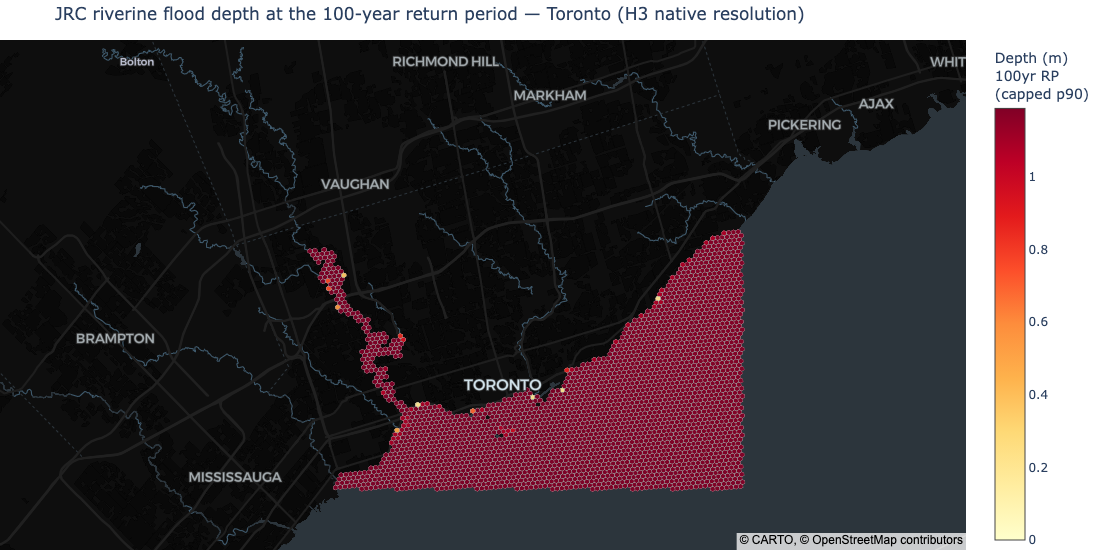

In [5]:
MAP_STYLE = "carto-darkmatter"  # dark basemap: low depths stay legible, unlike on a light one
depths_design_rp = depths[depths["return_period"] == DESIGN_RETURN_PERIOD]

hex_geojson = {
    "type": "FeatureCollection",
    "features": [
        {"type": "Feature", "id": str(cell), "geometry": mapping(cell_polygon(cell))}
        for cell in depths_design_rp["cell"]
    ],
}

# A handful of extreme (possibly artifact) cells would otherwise stretch the
# scale so far that the other 90% of (still meaningful) depths all read as
# the same pale color.
depth_cap = depths_design_rp["depth_m"].quantile(0.90)

fig_hex = go.Figure(
    go.Choroplethmap(
        geojson=hex_geojson,
        locations=depths_design_rp["cell"].astype(str),
        z=depths_design_rp["depth_m"],
        zmin=0,
        zmax=depth_cap,
        colorscale="YlOrRd",
        marker_line_width=0.3,
        marker_line_color="#999999",
        marker_opacity=0.95,
        colorbar_title=f"Depth (m)<br>{DESIGN_RETURN_PERIOD}yr RP<br>(capped p90)",
    )
)
fig_hex.update_layout(
    map_style=MAP_STYLE,
    map_zoom=9.5,
    map_center={"lat": (BOUNDS[1] + BOUNDS[3]) / 2, "lon": (BOUNDS[0] + BOUNDS[2]) / 2},
    margin=dict(l=0, r=0, t=40, b=0),
    title=(
        f"JRC riverine flood depth at the {DESIGN_RETURN_PERIOD}-year return period "
        "— Toronto (H3 native resolution)"
    ),
)
fig_hex.show()

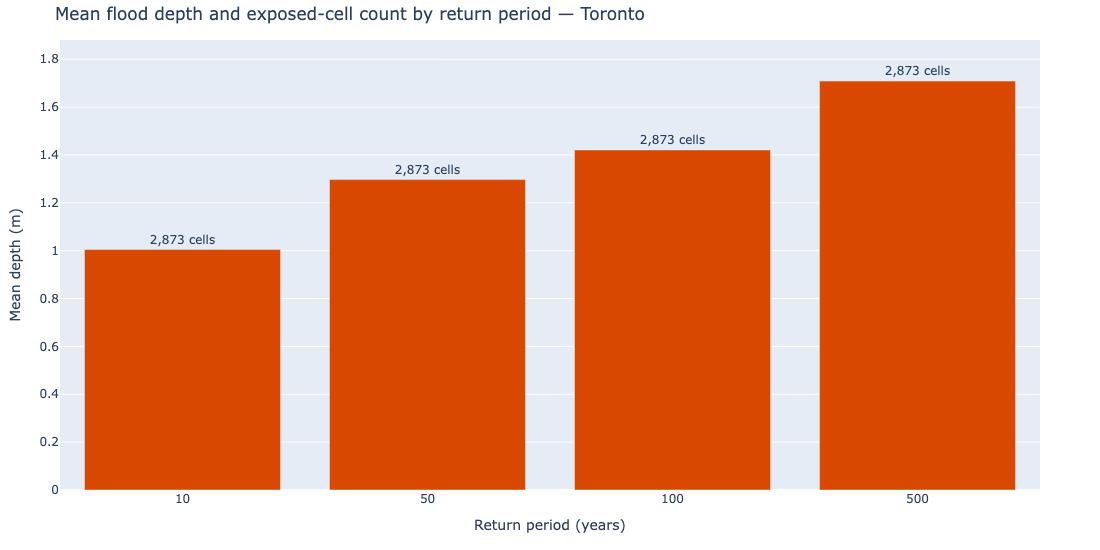

In [6]:
ranked = summary.sort_values("return_period")
fig_escalation = go.Figure(
    go.Bar(
        x=[str(rp) for rp in ranked["return_period"]],
        y=ranked["mean_depth_m"],
        marker_color="#D94801",
        text=ranked["exposed_cells"],
        texttemplate="%{text:,} cells",
        textposition="outside",
        customdata=ranked[["max_depth_m"]],
        hovertemplate=(
            "RP %{x}yr<br>Mean depth: %{y:.2f} m"
            "<br>Max depth: %{customdata[0]:.2f} m<extra></extra>"
        ),
    )
)
fig_escalation.update_layout(
    title="Mean flood depth and exposed-cell count by return period — Toronto",
    xaxis_title="Return period (years)",
    yaxis_title="Mean depth (m)",
    margin=dict(l=60, r=60, t=40, b=60),
)
fig_escalation.show()

## Scaling this up

[`pipelines/jrc_flood_pipeline.py`](https://github.com/RiskThinking/crc-docs/blob/main/pipelines/jrc_flood_pipeline.py) is this notebook's headless twin: the same area → AOI cache → canonical Parquet workflow with explicit reuse, refresh, and offline cache modes. Widen `--bounds` to scale the run; source discovery remains inside the plan and raster reads remain strip-bounded.